In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, GRU

In [58]:
test_df = pd.read_csv('/content/drive/MyDrive/Gooogle_Stock_Price/Google_Stock_Price_Test.csv')
train_df = pd.read_csv('/content/drive/MyDrive/Gooogle_Stock_Price/Google_Stock_Price_Train.csv')

In [20]:
train_df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [21]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   object 
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   object 
 5   Volume  1258 non-null   object 
dtypes: float64(3), object(3)
memory usage: 59.1+ KB


In [22]:
train_df.describe()

,Open,High,Low
count,1258.000000,1258.000000,1258.000000
mean,533.709833,537.880223,529.007409
std,151.904442,153.008811,150.552807
min,279.120000,281.210000,277.220000
25%,404.115000,406.765000,401.765000
50%,537.470000,540.750000,532.990000
75%,654.922500,662.587500,644.800000
max,816.680000,816.680000,805.140000


In [23]:
test_df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"


In [24]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    20 non-null     object 
 1   Open    20 non-null     float64
 2   High    20 non-null     float64
 3   Low     20 non-null     float64
 4   Close   20 non-null     float64
 5   Volume  20 non-null     object 
dtypes: float64(4), object(2)
memory usage: 1.1+ KB


In [25]:
X_train = train_df.loc[:, ['Open']].values
X_train[:5]

array([[325.25],
       [331.27],
       [329.83],
       [328.34],
       [322.04]])

In [26]:
from sklearn.preprocessing import MinMaxScaler

In [27]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled[:5]

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       [0.09156187],
       [0.07984225]])

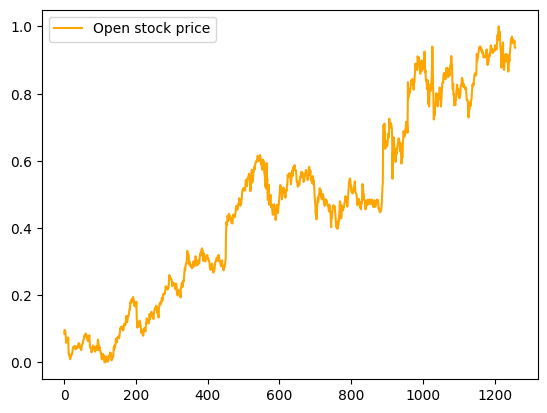

In [28]:
plt.plot(X_train_scaled, label='Open stock price', color='orange')
plt.legend()
plt.show()

In [29]:
len(X_train_scaled)

1258

In [30]:
X_train_data = []
y_train_data = []
timesteps = 50

for i in range(timesteps, len(X_train_scaled)):
  X_train_data.append(X_train_scaled[i-timesteps:i, 0])
  y_train_data.append(X_train_scaled[i, 0])

In [33]:
X_train_data, y_train_data = np.array(X_train_data), np.array(y_train_data)

In [34]:
y_train_data

array([0.05214302, 0.05612397, 0.05818885, ..., 0.95725128, 0.93796041,
       0.93688146])

In [45]:
X_train_data = np.reshape(X_train_data, (X_train_data.shape[0], X_train_data.shape[1], 1))
X_train_data.shape

(1208, 50, 1)

In [46]:
from keras.layers import SimpleRNN
from keras.layers import Dropout

In [47]:
X_train_data.shape[1]

50

In [50]:
simpleRNN = Sequential([
    Input(shape=(X_train_data.shape[1], 1)),
    SimpleRNN(units=50, activation='tanh', return_sequences=True),
    Dropout(0.2),

    SimpleRNN(units=50, activation='tanh', return_sequences=True),
    Dropout(0.2),

    SimpleRNN(units=50, activation='tanh', return_sequences=True),
    Dropout(0.2),

    SimpleRNN(units=50),
    Dropout(0.2),

    Dense(units=1)
])

simpleRNN.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

history = simpleRNN.fit(X_train_data, y_train_data, epochs=100, batch_size=32, verbose=0)

In [51]:
simpleRNN.evaluate(X_train_data, y_train_data)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 8.7981e-04


0.0008798058843240142

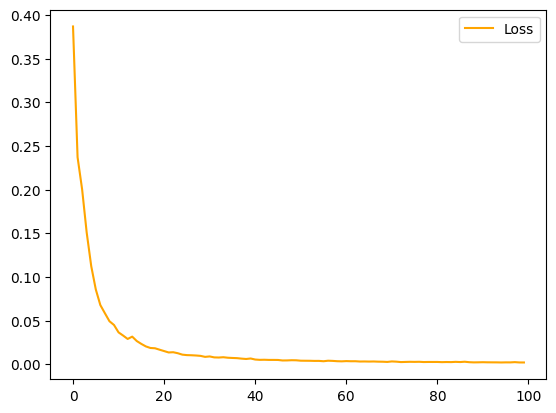

In [53]:
plt.plot(history.history['loss'], label='Loss', color='orange')
plt.legend()
plt.show()

In [65]:
total_df = pd.concat((train_df['Open'], test_df['Open']), axis=0)
total_df

,Open
0,325.25
1,331.27
2,329.83
3,328.34
4,322.04
...,...
15,829.62
16,837.81
17,834.71
18,814.66


In [66]:
inputs = total_df[len(total_df) - len(test_df) - timesteps:].values.reshape(-1, 1)
inputs[:5]

array([[803.3 ],
       [795.  ],
       [804.9 ],
       [816.68],
       [806.34]])

In [67]:
scaled_inputs = scaler.transform(inputs)
scaled_inputs[:10]

array([[0.97510976],
       [0.95966962],
       [0.97808617],
       [1.        ],
       [0.98076494],
       [0.97083116],
       [0.98450406],
       [0.96054394],
       [0.9371419 ],
       [0.92841729]])

In [68]:
X_test = []

for i in range(timesteps, 70):
  X_test.append(scaled_inputs[i-timesteps:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [70]:
y_pred_scaled = simpleRNN.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [72]:
true_stock = test_df.loc[:, ['Open']].values
true_stock[:5]

array([[778.81],
       [788.36],
       [786.08],
       [795.26],
       [806.4 ]])

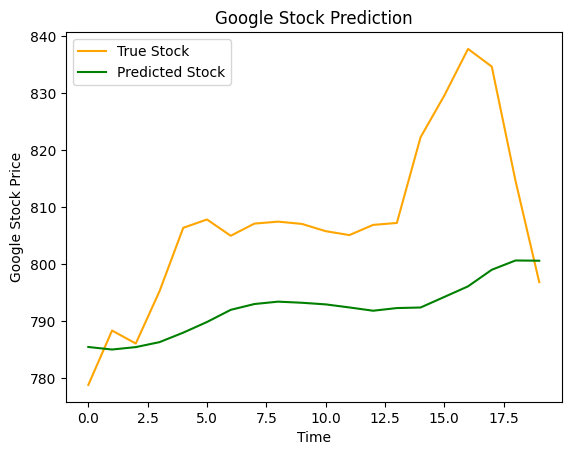

In [74]:
plt.plot(true_stock, label='True Stock', color='orange')
plt.plot(y_pred, label='Predicted Stock', color='green')
plt.title('Google Stock Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()

### LSTM  

In [81]:
LSTM_RNN = Sequential([
    Input(shape=(X_train_data.shape[1], 1)),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),

    LSTM(units=50, return_sequences=True),
    Dropout(0.2),

    LSTM(units=50, return_sequences=True),
    Dropout(0.2),

    LSTM(units=50),
    Dropout(0.2),

    Dense(units=1)
])

LSTM_RNN.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

history = LSTM_RNN.fit(X_train_data, y_train_data, epochs=100, batch_size=16, verbose=0)

In [82]:
LSTM_RNN.evaluate(X_train_data, y_train_data)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.5834e-04


0.0005583363235928118

In [83]:
y_pred_scaled_lstm = LSTM_RNN.predict(X_test)
y_pred_lstm = scaler.inverse_transform(y_pred_scaled_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


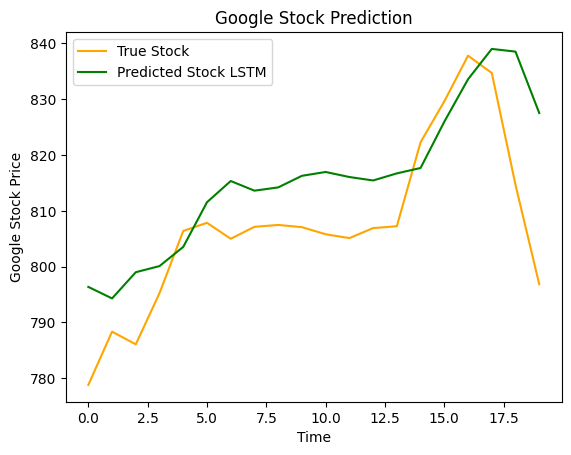

In [84]:
plt.plot(true_stock, label='True Stock', color='orange')
plt.plot(y_pred_lstm, label='Predicted Stock LSTM', color='green')
plt.title('Google Stock Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()

### GRU

In [86]:
GRU_RNN = Sequential([
    Input(shape=(X_train_data.shape[1], 1)),
    GRU(units=50, return_sequences=True),
    Dropout(0.2),

    GRU(units=50, return_sequences=True),
    Dropout(0.2),

    GRU(units=50, return_sequences=True),
    Dropout(0.2),

    GRU(units=50),
    Dropout(0.2),

    Dense(units=1)
])

GRU_RNN.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

history = GRU_RNN.fit(X_train_data, y_train_data, epochs=100, batch_size=16, verbose=0)

In [87]:
GRU_RNN.evaluate(X_train_data, y_train_data)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 5.0360e-04


0.0005035960930399597

In [88]:
y_pred_scaled_gru = GRU_RNN.predict(X_test)
y_pred_gru = scaler.inverse_transform(y_pred_scaled_gru)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


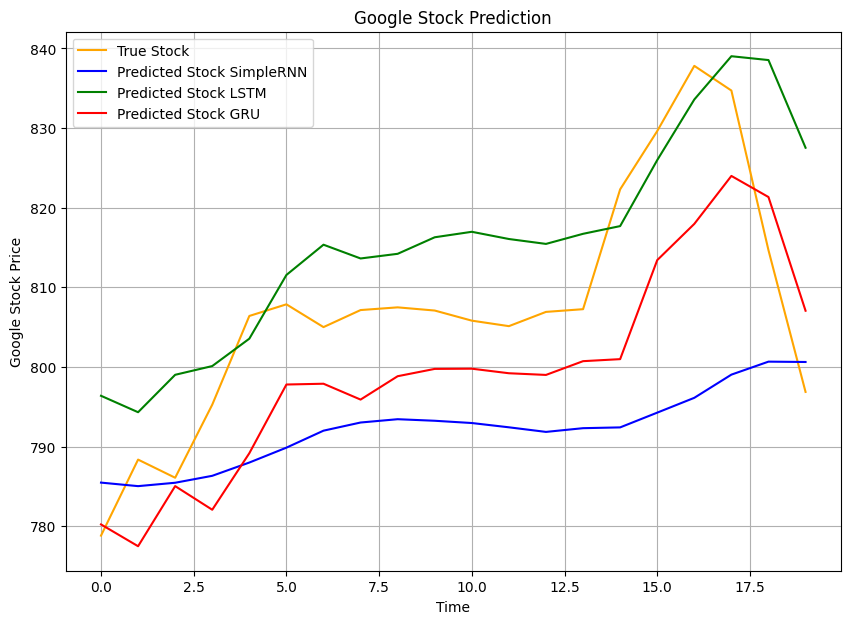

In [95]:
plt.figure(figsize=(10, 7))
plt.plot(true_stock, label='True Stock', color='orange')
plt.plot(y_pred, label='Predicted Stock SimpleRNN', color='blue')
plt.plot(y_pred_lstm, label='Predicted Stock LSTM', color='green')
plt.plot(y_pred_gru, label='Predicted Stock GRU', color='red')
plt.title('Google Stock Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.grid()
plt.legend()
plt.show()